<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/Medium/TensorFlow/TF3_ANN_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Model, Sequential, layers, optimizers, losses, metrics
from keras.preprocessing.image import ImageDataGenerator

## Artificial Neural Network with a tabular data

### Data Loading

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"hbahruz","key":"4f925bc35f1b4f8677fc6f8061cceb06"}'}

In [4]:
!kaggle datasets download -d yasserh/titanic-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
  0% 0.00/22.0k [00:00<?, ?B/s]
100% 22.0k/22.0k [00:00<00:00, 22.9MB/s]


In [5]:
import zipfile

dzip = 'titanic-dataset.zip'

def extract_zip(file_path, extract_to='.'):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

extract_zip(dzip, 'titanic-dataset')

In [6]:
import pandas as pd

df = pd.read_csv('titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Preprocessing

In [7]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [8]:
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [9]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0.0
1,1,1,0,38.0,1,0,71.2833,1.0
2,1,3,0,26.0,0,0,7.9250,0.0


In [10]:
df.dropna(inplace=True)

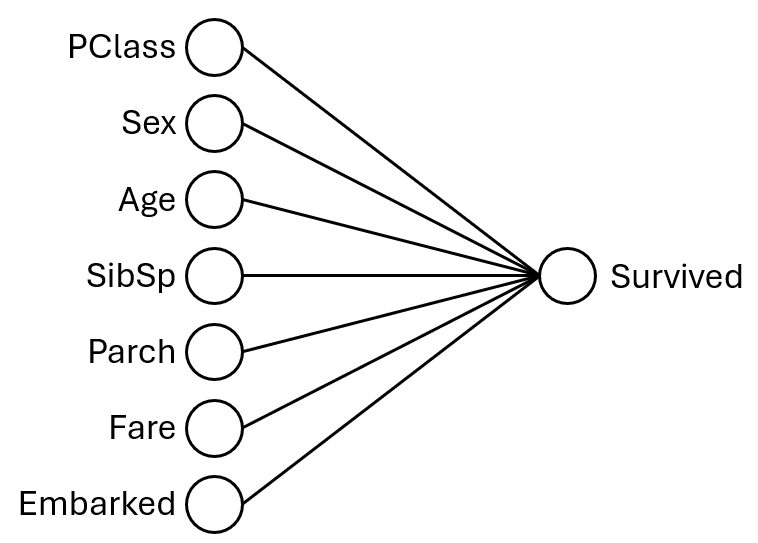

In [12]:
from PIL import Image
Image.open("Features_as_Neurons.png")

#### Train and Test split

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=40)

#### Callback
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback <br>

#### Callback - on_epoch_end
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback#on_epoch_end
    

In [14]:
class TitanicCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_threshold = 0.7):
        self.val_threshold = val_threshold

    # Early Stopping
    def on_epoch_end(self, epoch, logs={}):
        val_acc = logs.get('val_accuracy')
        if(val_acc > self.val_threshold):
            print(f"\nValidation accuracy: {val_acc} which is higher than {self.val_threshold * 100}%, so cancelling training!")
            self.model.stop_training = True

### Model Building

In [15]:
titanic_model = Sequential([
    layers.Dense(32, activation='relu', input_shape=[X_train.shape[1]]), # 7 inputs
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

### Training and Validating

In [16]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
titanic_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
titanic_model.fit(X_train, y_train, epochs=200, validation_split=0.1, callbacks=[TitanicCallback(0.8)])

Epoch 1/200
18/18 [==============================] - 3s 24ms/step - loss: 0.8041 - accuracy: 0.5434 - val_loss: 0.6768 - val_accuracy: 0.5938
Epoch 2/200
18/18 [==============================] - 0s 7ms/step - loss: 0.6699 - accuracy: 0.6233 - val_loss: 0.6829 - val_accuracy: 0.5938
Epoch 3/200
18/18 [==============================] - 0s 7ms/step - loss: 0.6113 - accuracy: 0.6719 - val_loss: 0.7602 - val_accuracy: 0.5469
Epoch 4/200
18/18 [==============================] - 0s 7ms/step - loss: 0.6217 - accuracy: 0.6788 - val_loss: 0.6846 - val_accuracy: 0.6094
Epoch 5/200
18/18 [==============================] - 0s 7ms/step - loss: 0.6222 - accuracy: 0.6510 - val_loss: 0.6788 - val_accuracy: 0.5938
Epoch 6/200
18/18 [==============================] - 0s 10ms/step - loss: 0.6275 - accuracy: 0.6997 - val_loss: 0.7357 - val_accuracy: 0.5781
Epoch 7/200
18/18 [==============================] - 0s 9ms/step - loss: 0.6226 - accuracy: 0.6667 - val_loss: 0.7145 - val_accuracy: 0.5625
Epoch 8/200

### Testing

In [18]:
test_loss, test_accuracy = titanic_model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

3/3 [==============================] - 0s 5ms/step - loss: 0.5380 - accuracy: 0.7361
Test Loss: 0.5380194187164307
Test Accuracy: 0.7361111044883728


## Introduction to Convolutional Neural Network

### Data Preparation

In [ ]:
!kaggle datasets download -d akhiljethwa/forest-vs-desert

Dataset URL: https://www.kaggle.com/datasets/akhiljethwa/forest-vs-desert
License(s): CC-BY-NC-SA-4.0
 66% 5.00M/7.54M [00:00<00:00, 42.7MB/s]
100% 7.54M/7.54M [00:00<00:00, 57.0MB/s]


In [ ]:
import zipfile

dzip = 'forest-vs-desert.zip'

def extract_zip(file_path, extract_to='.'):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

extract_zip(dzip, 'forest_vs_desert')

In [ ]:
img_height, img_width = 64, 64

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'forest_vs_desert/Data',
    validation_split=0.2,  # Use 20% of training data for validation
    subset="training",
    seed=123,
    image_size=(img_height, img_width)
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'forest_vs_desert/Data',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width)
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=1024)
val_ds = val_ds.cache().prefetch(buffer_size=1024)

Found 802 files belonging to 2 classes.
Using 642 files for training.
Found 802 files belonging to 2 classes.
Using 160 files for validation.


### Model Building

#### Convolution
<img src = "https://analyticsindiamag.com/wp-content/uploads/2018/01/conv-full-layer.gif">

#### Max and Average Pooling
<img src = "https://miro.medium.com/v2/resize:fit:1400/1*fXxDBsJ96FKEtMOa9vNgjA.gif">

#### Flatten
<img src = "https://sds-platform-private.s3-us-east-2.amazonaws.com/uploads/73_blog_image_1.png">

### Dense or Fully Connected Layers
<img src = "https://cdn.analyticsvidhya.com/wp-content/uploads/2020/02/ANN-Graph.gif">

In [ ]:
model = Sequential([
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]),
    layers.MaxPool2D(pool_size=2, strides=2),
    layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPool2D(pool_size=2, strides=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

### Callback

In [ ]:
class CNNCallback(tf.keras.callbacks.Callback):
    # Early Stopping
    def on_epoch_end(self, epoch, logs={}):
        val_acc = logs.get('val_accuracy')
        if(val_acc > 0.97):
            print(f"\nValidation accuracy: {val_acc} which is higher than 97%, so cancelling training!")
            self.model.stop_training = True

callbacks = CNNCallback()

### Training and Validating

In [ ]:
epochs = 5
learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss_fn = losses.SparseCategoricalCrossentropy()

model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

In [ ]:
model.fit(x=train_ds, validation_data=val_ds, epochs=epochs, callbacks=[callbacks])

Epoch 1/5
21/21 [==============================] - 26s 212ms/step - loss: 0.4262 - accuracy: 0.9673 - val_loss: 0.3716 - val_accuracy: 0.9688
Epoch 2/5
21/21 [==============================] - ETA: 0s - loss: 0.0429 - accuracy: 0.9938
Validation accuracy: 0.981249988079071 which is higher than 97%, so cancelling training!
21/21 [==============================] - 3s 161ms/step - loss: 0.0429 - accuracy: 0.9938 - val_loss: 0.2985 - val_accuracy: 0.9812
